In [1]:
import config
import torch
import sys
sys.path.append('../util')
sys.path.append('../others_networks')
from Trainer import Trainer
from util import show_dataset_prev
from GenericDatasetReader import get_datasets

from DeepLabV3 import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
result_path = './DeepLabV3/'

In [2]:
# from util import compile_xls_best_results
# compile_xls_best_results(result_path, output_file="deeplabv3.xlsx")

In [3]:
num_classes  = config.num_classes
in_channels  = config.in_channels
out_channels = 3

train_loader, test_loader, val_loader = get_datasets(dataset_dir=config.dataset_path, 
                                              resolution=config.dataset_resolution, 
                                              batch_size=config.batch_size,
                                              num_classes=num_classes)

torch.Size([16, 3, 256, 256]) torch.Size([16, 1, 256, 256])
4814 198 198


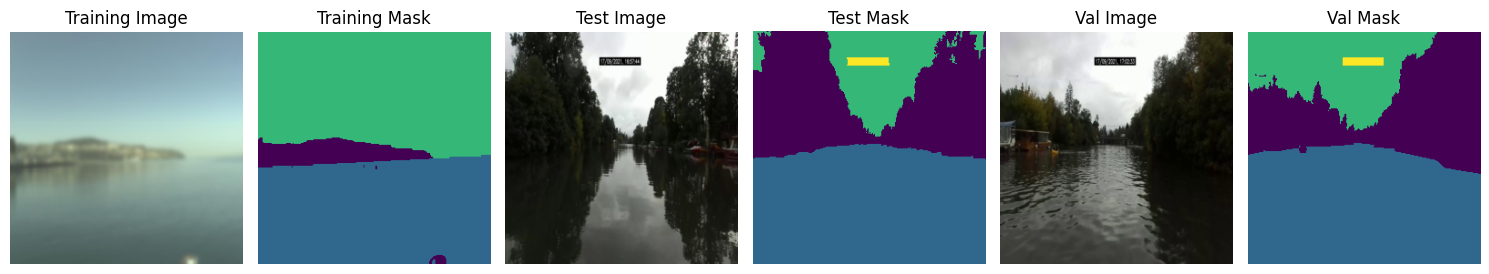

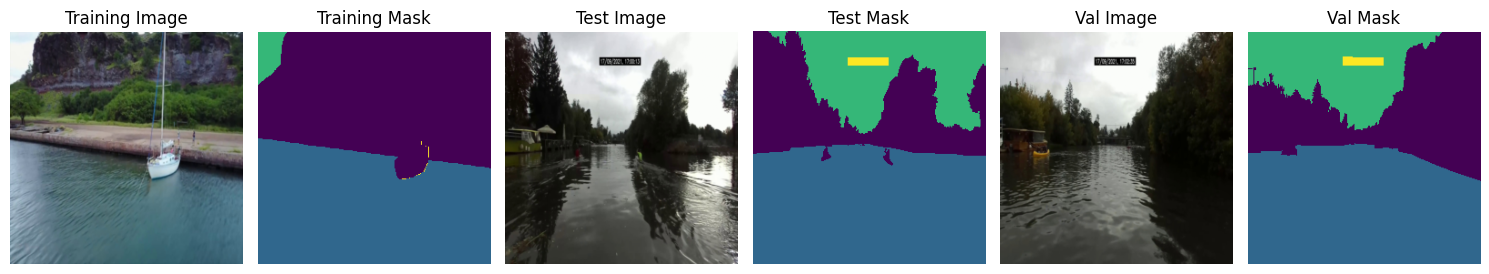

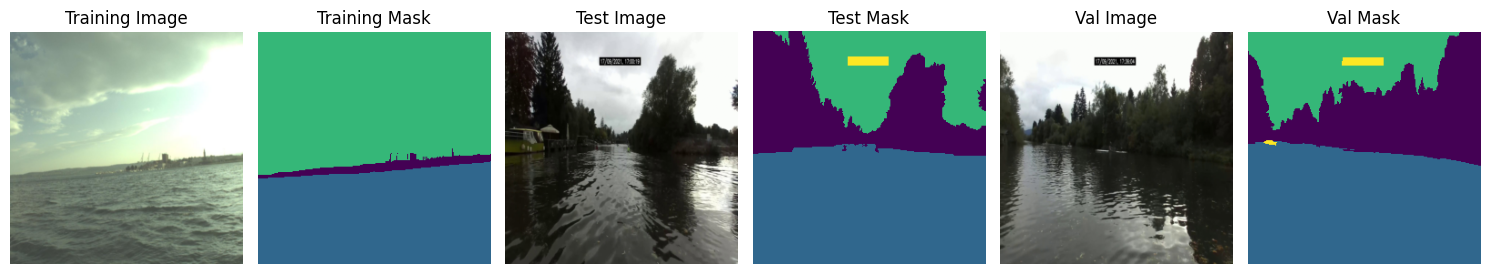

In [4]:
for (images_train, masks_train), (images_test, masks_test) in zip(train_loader, test_loader):
    print(images_train.shape, masks_train.shape)
    break

print(len(train_loader.dataset), len(test_loader.dataset), len(val_loader.dataset))

show_dataset_prev(train_loader, test_loader, val_loader, num_images=3, num_classes=num_classes)

In [7]:
def train(model, model_name=None, epochs=300, re_evaluate=True):
    model_filename = f'{model_name}-epochs{epochs}.pth'

    
    trainer = Trainer(num_classes=num_classes,
                    model_filename=model_filename, 
                    model_dir=result_path, 
                    save_xlsx=True,
                    ignore_index=255)
    model = trainer.train(model, train_loader, val_loader, test_loader,
                            num_epochs=epochs, 
                            verbose=1, 
                            save_every=5, 
                            learning_rate=1e-3,
                            continue_from_last=True,
                            # we are re-evaluating after loading the model 
                            # because we refactored the code and want to see the new results
                            re_evaluate=re_evaluate)
    model.to(device)
    return trainer.get_best_test_stats()



In [8]:
model = DeepLabV3MobilenetV2Wrapper(in_channels=in_channels, out_channels=out_channels)
stats1 = train(model,'DeepLabV3MobilenetV2Wrapper-1')

Device: cuda
Trainable_parameters: 12648451
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-1-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9689 mIoU: 0.9412 Prec: 0.9701 Recall: 0.9677 Q: 0.9121
Loading best version.
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-1-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9686 mIoU: 0.9407 Prec: 0.9693 Recall: 0.9679 Q: 0.9113
Latest version has the best f1-score on [testset]: latest(0.9689) best(0.9686)
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-1-epochs300.pth
Latest version loaded.


In [9]:
model = DeepLabV3MobilenetV2Wrapper(in_channels=in_channels, out_channels=out_channels)
stats2 = train(model,'DeepLabV3MobilenetV2Wrapper-2')

Device: cuda
Trainable_parameters: 12648451
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-2-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9676 mIoU: 0.9388 Prec: 0.9699 Recall: 0.9654 Q: 0.9084
Loading best version.
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-2-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9667 mIoU: 0.9372 Prec: 0.9693 Recall: 0.9642 Q: 0.9061
Latest version has the best f1-score on [testset]: latest(0.9676) best(0.9667)
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-2-epochs300.pth
Latest version loaded.


In [10]:
model = DeepLabV3MobilenetV2Wrapper(in_channels=in_channels, out_channels=out_channels)
stats3 = train(model,'DeepLabV3MobilenetV2Wrapper-3')

Device: cuda
Trainable_parameters: 12648451
Loss function: Losses.BCEDiceLoss
Reevaluate is on
Trained model already exists. 
Loading latest version.
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-3-epochs300.pth
Evaluating the latest version...
Loss: 0.0000 F1: 0.9689 mIoU: 0.9413 Prec: 0.9709 Recall: 0.9671 Q: 0.9122
Loading best version.
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-3-epochs300-best.pth
Evaluating the best version...
Loss: 0.0000 F1: 0.9689 mIoU: 0.9411 Prec: 0.9706 Recall: 0.9672 Q: 0.9119
Latest version has the best f1-score on [testset]: latest(0.9689) best(0.9689)
Loaded model: ./DeepLabV3//DeepLabV3MobilenetV2Wrapper-3-epochs300.pth
Latest version loaded.


In [11]:
print("AVG F1-Score:", round((stats1['f1']+stats2['f1']+stats3['f1'])/3.0,3) )
print("Max F1-Score:", round(max(stats1['f1'],stats2['f1'],stats3['f1']),3) )

print("AVG mIoU:", round((stats1['miou']+stats2['miou']+stats3['miou'])/3.0,3) )
print("AVG mIoU:", round(max(stats1['miou'],stats2['miou'],stats3['miou']),3) )

AVG F1-Score: 0.968
Max F1-Score: 0.969
AVG mIoU: 0.94
AVG mIoU: 0.941
